In [2]:
import wget
import os
import healpy as hp
import numpy as np
import pylab as pl 
from pathlib import Path
import scipy
from scipy.optimize import curve_fit
from astropy.io import fits
from reproject import reproject_to_healpix

from astropy import units as u, constants as const


def b(nu):
    """
    estimate dI/dT_CMB as defined in eq. 8 of Planck 2013 IX
    """
    nu0 = 56.8 * u.GHz
    x = nu / nu0
    Tcmb = 2.7255 * u.K
    bb = (
        2
        * const.h
        * nu ** 3
        / const.c ** 2
        / Tcmb
        * (x * np.exp(x) / (np.exp(x) - 1) ** 2)
    )
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)


def b_rj(nu):
    """
    estimate dI/dT_RJ as defined in eq. 30 of Planck 2013 IX
    """
    bb = 2 * const.k_B * nu ** 2 / const.c ** 2
    return bb.to(u.W / u.m ** 2 / u.K / u.Hz)

def brightness2Tcmb(nu, bandpass=None):
    """
    Convert from Jy/srad  to K_CMB
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def brightness2Trj(nu, bandpass=None):
    """
    Convert from Jy/srad to K_RJ
    """
    try:
        nu.unit
    except AttributeError:
        nu *= u.GHz

    if bandpass is None:
        integrand = b_rj(nu)
        conversion_factor = 1 / integrand
    else:
        bandpass /= u.GHz
        integrand = b_rj(nu) * bandpass
        conversion_factor = 1 / np.trapz(integrand, x=(nu))
    return conversion_factor


def Krj2Kcmb(nu, Trj=1.0, bandpass=None):
    """
    Convert antenna temperature ( Rayleigh-Jeans) into the physical one
    """
    return Trj / Kcmb2Krj(
        nu=nu, Tcmb=1, bandpass=bandpass
    )  # (x ** 2 * np.exp(x) / (np.exp(x) - 1) ** 2)


def Kcmb2Krj(nu, Tcmb=1.0, bandpass=None):
    return (
        brightness2Trj(nu=nu, bandpass=bandpass)
        / brightness2Tcmb(nu=nu, bandpass=bandpass)
        * Tcmb
    )



In [3]:
from scipy.odr import Model, Data, ODR
from scipy.stats import linregress

def rotate_map(mapin, coord_in , coord_out ) : 
    alm = hp.map2alm (mapin )
    R=  hp.Rotator(coord=[coord_in, coord_out ])
    alm =  R.rotate_alm (alm )
    map_out = hp.alm2map (alm , nside= hp.get_nside(mapin ))
    return map_out


def get_betas(xdat, xnoise, ydat, ynoise, v1, v2):
    """perform linear regression between two data set and get spectral index """

    mydata = Data(xdat, ydat, wd=xnoise**-2, we=ynoise**-2)
    myodr = ODR(mydata, Model(sform), beta0=[0.05, 0.5])
    myoutput = myodr.run()
    fitted_gradient = myoutput.beta[0]
    error_gradient = myoutput.sd_beta[0]

    ef = np.log(v2/v1)
    beta = np.log(fitted_gradient) / ef
    beta_error = error_gradient / (fitted_gradient * ef)

    #if beta > -2.1 or beta < -3.5:
    #    plt.plot(xdat, ydat, '.')
    #    plt.plot(xdat, fitted_gradient*xdat +  myoutput.beta[1], 'r-')
    #    plt.show()

    #    print("breaking here")
    
    return beta, beta_error, myoutput 
    
def sform(param, xxx):
    '''linear reggression'''
    return xxx * param[0] + param[1]
def fitting_beta_curvature(X, beta, cs):
   return beta*X +cs*X*X 

def sfunc(xxx, bval, cval):
    '''linear reggression'''
    return xxx * bval + cval


def remove_off(map, hasmap, maperr, haserr):

    corrmax = 0.85

    nside_superpix=8
    nan1 =np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)

    try : 
        ang = hp.pix2ang(ipix= pixs[nan1][0] , nside= hp.get_nside(map)) 
        pix1 = hp.ang2pix(theta=ang[0] , phi = ang[1] , nside= nside_superpix)
    

        if pixs[nan1] [0]==0 :
            print("Southern Survey ") 
            super_pixs=  np.arange(pix1, hp.nside2npix(nside_superpix)) 
        else: 
            print("Northern survey ")
            super_pixs=  np.arange(pix1) 
    except IndexError: 
        print('Fullsky survey')
        super_pixs=  np.arange(hp.nside2npix(nside_superpix )) 
    offsets = np.zeros_like(super_pixs)*1. 
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)  
   

    nansize =0 
    for jj, ipix in enumerate(super_pixs) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:           
            errx = haserr[patch] * hasmap[patch]
            erry =  maperr * map[patch]
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]
        
            if np.corrcoef(hasmap[patch].value, map[patch].value)[0,1] > corrmax:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan 
            
    offmap[super_pixs] = offsets 

    avec = np.nanmean( offsets ) *map.unit 
    map = map - avec
    if offsets.size - nansize < 2:
        print("Issue")
    o_err = np.nanstd(offsets) /np.sqrt(offsets.size - nansize)
    
    return map, avec, o_err, offmap 
 


https://lambda.gsfc.nasa.gov/product/wmap/dr5/ 

https://lambda.gsfc.nasa.gov/product/foreground/fg_all_sky150_mhzmap_get.html



https://lambda.gsfc.nasa.gov/data/map/dr5/skymaps/9yr/deconv/images/wmap_band_deconv_imap_r9_9yr_K_v5.fits

https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/haslam408_ds_Remazeilles2014.fits

https://lda10g.alliance.unm.edu/LWA1LowFrequencySkySurvey/
https://lambda.gsfc.nasa.gov/data/foregrounds/lwa1/healpix-all-sky-rav-wsclean-map-50.fits

https://lambda.gsfc.nasa.gov/product/foreground/fg_rhodes_hart_info.html


## Read inputs

In [ ]:
maps={}
mapserr={}
offerr={}

cwd = Path.cwd()

fstring ="MAIPU_MU_1_64.fits"
try :
    print(f"reading {fstring} ")

    maps[45],_=  hp.read_map(f"../southern_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/maipu_45/{fstring}", out ="../southern_data")
    maps[45]=  hp.read_map(f"../southern_data/{fstring}"  )

maps[45] = hp.ud_grade(maps[45], 256)
zeros = maps[45] < 0. 
maps[45][zeros]  =  np.nan  
maps[45]*=u.K
mapserr[45] = 0.07 # 7 per cent for mapu calibration
offerr[45] = 0.0

fstring ="lambda_landecker_wielebinski_150MHz_hpx_r8.fits"
try :
    print(f"reading {fstring} ")

    maps[150],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/landecker_150/{fstring}", out ="../lwa_data")
    maps[150]=  hp.read_map(f"../lwa_data/{fstring}"  )


maps[150] = (maps[150] * u.K ).to(maps[45].unit )
mapserr[150] = 0.05 # 5 per cent for 150 calibration
offerr[150] = 0.0

fstring="haslam408_ds_Remazeilles2014.fits"

try :
    print(f"reading {fstring} ")

    maps[408],_=  hp.read_map(f"../lwa_data/{fstring}" ,h=True  )  
except FileNotFoundError: 
    filename = wget.download( f"https://lambda.gsfc.nasa.gov/data/foregrounds/haslam_2014/{fstring}", out ="../lwa_data")
    maps[408]=  hp.read_map(f"../lwa_data/{fstring}"  )


maps[408]= (maps[408]*u.K -8.9*u.K ).to(maps[45].unit)
mapserr[408] = np.sqrt((0.1 * maps[408].value)**2 + 1.3**2) /  maps[408].value # 10 per cent for 408 calibration plus the 1.3K offset error
offerr[408] = 0.0 # it has already been added to maperr


 

print(f"reading {fstring} ")


hdul = fits.open("../inputmaps/staps_southern_healpix_K.fits" )


cols = hdul[1].columns.names

hdul.close() 
stapmaps = hp.read_map("../southern_data/staps_southern_healpix_K.fits" , field=cols  )
for k,m  in zip(cols, stapmaps ):

    maps[int(k)]= (m * u.K)    .to(maps[45].unit) 
    offerr[int(k)] = 0.0
    mapserr[int(k)] = 0.1 # 10 per cent for staps calibration   





nside= hp.get_nside(maps[45] )
npix= hp.nside2npix(nside)

freqs  =  np.array([  k for k in maps.keys()  ])  

reading MAIPU_MU_1_64.fits 
reading lambda_landecker_wielebinski_150MHz_hpx_r8.fits 
reading haslam408_ds_Remazeilles2014.fits 
reading staps.i.E.smooth.K.fits 


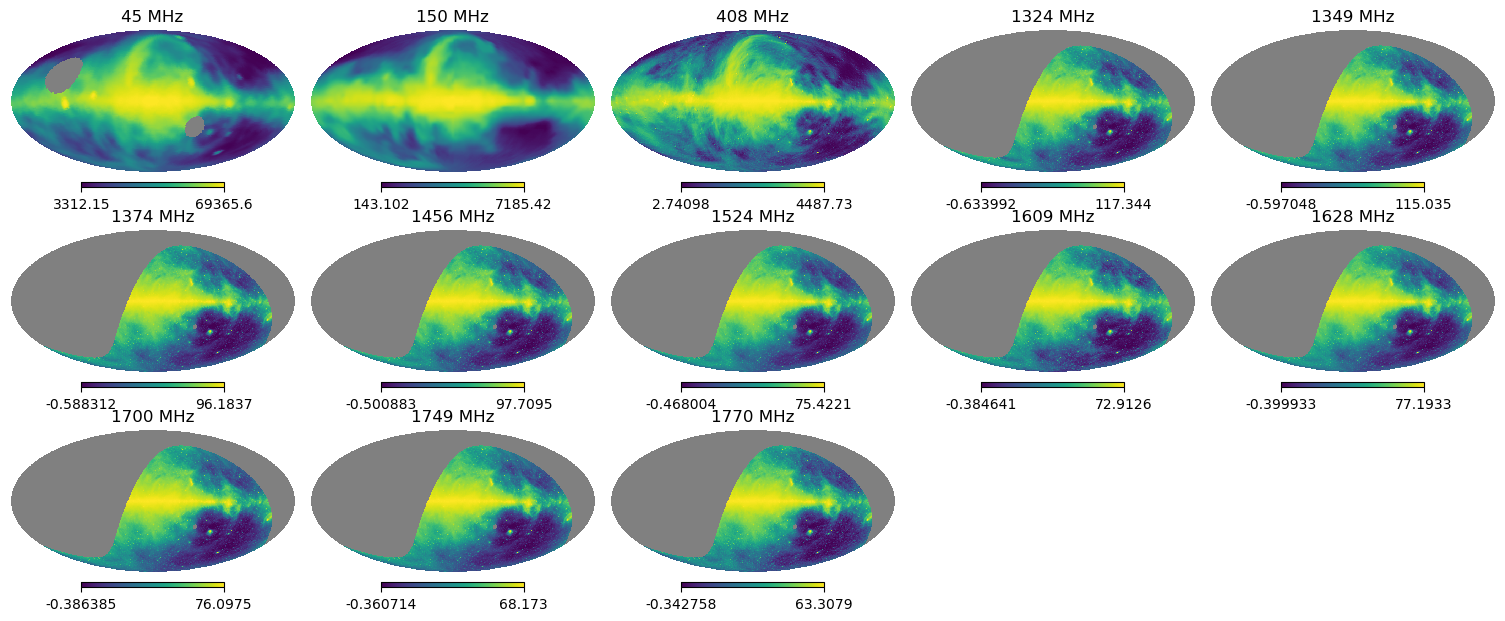

In [10]:
pl.figure(figsize=(15,10)) 

j=0
for fr,m in maps.items():
     
    hp.mollview( (m.value),  title=f'{fr} MHz'  , sub=(5,5,1+j) , notext=True ,norm='hist'   )
    
    j+=1

## Smoothing to common reso

In [11]:


fwhms = {45: 5.0*u.deg, 
         150: 5. *u.deg , 
         159: 3.1 *u.deg , 
       408 :56*u.arcmin,
       1324: 20.0*u.arcmin, 
       1349: 20.0*u.arcmin,
       1374: 20.0*u.arcmin,  
       #1400: 35.4*u.arcmin,
       1456: 20.0*u.arcmin, 
       1524: 20.*u.arcmin,
       1600: 20.*u.arcmin,
       1609: 20.*u.arcmin,
       1628: 20.*u.arcmin,
       1700: 20.*u.arcmin,
       1749: 20.*u.arcmin,
       1770: 20.*u.arcmin,
       2300: 8.9 *u.arcmin,
       2326: 20.0 *u.arcmin, 
        }

idmax = np.argmax([fwhms[f] .to(u.arcmin).value  for f in maps .keys()] )
fwhmax= fwhms[freqs[idmax]] 

## smooth maps to lowest  reso  
# downgrade them to nside=256 
print("smoothing and downgrading maps ")

for k  in freqs:
    if k!=freqs[idmax]:  
        nans= np.ma.masked_invalid(maps[k] ).mask
        maps[k] [nans] =hp.UNSEEN *maps[k].unit
        maps[k] = hp.smoothing(maps[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
    if hp.get_nside(maps[k]) != nside  : 
        maps[k] = hp.ud_grade(maps[k].value , nside_out=nside )*maps[k].unit
    if k == 408:
      mapserr[k] = hp.smoothing(mapserr[k]  , fwhm=pl.sqrt(fwhmax**2 - fwhms[k] **2 ).to(u.rad).value  )*maps[k].unit
      mapserr[k] = hp.ud_grade(mapserr[k].value , nside_out=nside )*maps[k].unit

    nans= np.ma.masked_equal(maps[k].value, hp.UNSEEN  ).mask
    maps[k][nans] = np.nan 

smoothing and downgrading maps 


## RMS noise estimates 


In [ ]:


errors ={} 

#replicating fig.7  of   https://www.aanda.org/articles/aa/pdf/2025/02/aa53326-24.pdf


x1=min(freqs[freqs>1000] );x2=max(freqs[freqs>1000])
y1= 16 *u.mK ; y2= 8*u.mK 
stapsnoise = lambda f: y1 + (y2 -y1) * ( (f - x1) / (x2 - x1) ) 
for fs, m in maps.items(): 
    if fs >1000 : 
        errors [fs] = stapsnoise(fs).to(u.K ) 

errors[45 ]= 300 *u.K ##table 2 of https://aas.aanda.org/articles/aas/pdf/1997/11/ds1291.pdf 
errors[150]= 40 *u.K  #https://lambda.gsfc.nasa.gov/product/foreground/fg_all_sky150_mhzmap_info.html 
errors[408]= 0.1 *u.K # searching r.m.s. in https://arxiv.org/pdf/1411.3628 sigma_destr = 0.1 K 


storerrors ={} 
for f in maps.keys() : 
    storerrors[str(f)] = errors[f].value 

np.savez(f"../inputmaps/coarse_south_errors_dict.npz", **storerrors)


for k  in sorted(errors.keys())  : 
    print(f"At {k} MHz , map error is {errors[k]} ") 


At 45 MHz , map error is 300.0 K 
At 150 MHz , map error is 40.0 K 
At 408 MHz , map error is 0.1 K 
At 1324 MHz , map error is 0.016 K 
At 1349 MHz , map error is 0.015551569506726457 K 
At 1374 MHz , map error is 0.015103139013452914 K 
At 1456 MHz , map error is 0.013632286995515696 K 
At 1524 MHz , map error is 0.01241255605381166 K 
At 1609 MHz , map error is 0.010887892376681614 K 
At 1628 MHz , map error is 0.010547085201793722 K 
At 1700 MHz , map error is 0.00925560538116592 K 
At 1749 MHz , map error is 0.008376681614349776 K 
At 1770 MHz , map error is 0.008 K 


## Offset removal 

In [ ]:


offerr={}
off_map = {} 
offsetvals = {} 


offsetvals = {}
def remove_off(map, hasmap, maperr, haserr  ):
    nside_superpix=8
    nan1 =~np.ma.masked_invalid (map).mask 
    npix = map.size 
    pixs = np.arange(npix)
    super_nans = hp.ud_grade(nan1.astype('int'), nside_out=nside_superpix).astype('bool') 
    super_pixs = np.arange(super_nans.size ) [super_nans] 
     
    offsets = np.zeros_like(super_pixs  )*1. 
    offmap = np.full(hp.nside2npix(nside_superpix), np.nan)     
    nansize =0 

    for jj, ipix in enumerate(super_pixs ) : 

        super_map = np.zeros(hp.nside2npix(nside_superpix))
        super_map [ipix] =1
        

        patch =  (hp.ud_grade(super_map, nside_out=hp.get_nside(map))) .astype('bool')
     
        try:
            
            errx = haserr[patch] * hasmap[patch]
            erry =  maperr * map[patch]
            mydata = Data(hasmap[patch], map[patch], wd=errx**-2, we=erry**-2)
            myodr = ODR(mydata, Model(sform), beta0=[0.0, 0.0])
            myoutput = myodr.run()
            cfit = myoutput.beta[1]
            if np.corrcoef(hasmap[patch].value, map[patch].value)[0,1] > 0.75:
                offsets[jj] = cfit
            else:
                offsets[jj] = np.nan
        except  ValueError: 
            nansize+=1 
            offsets[jj]= np.nan 

    offmap[super_pixs] = offsets

    #avec = np.nanmean( offsets ) *map.unit
    avec = np.nanmedian( offsets ) *map.unit
    map = map - avec
    
    return map, avec  , np.nanstd(offsets) /np.sqrt(offsets.size - nansize), offmap 

for k in maps.keys():
    if k ==408 : continue
    maps[k], offsetvals[k], offerr[k], off_map[k] = remove_off(maps[k], maps[408], mapserr[k], mapserr[408])
    print(f" {k} MHz data estimated offset: {offsetvals[k]:.4f} ± {offerr[k]:.4f}")


 

 45 MHz data estimated offset: 3062.7291 K ± 115.1386
 150 MHz data estimated offset: 83.3432 K ± 6.0852
 1324 MHz data estimated offset: -0.8308 K ± 0.0196
 1349 MHz data estimated offset: -0.7735 K ± 0.0166
 1374 MHz data estimated offset: -0.7309 K ± 0.0154
 1456 MHz data estimated offset: -0.6349 K ± 0.0143
 1524 MHz data estimated offset: -0.5732 K ± 0.0134
 1609 MHz data estimated offset: -0.4864 K ± 0.0115
 1628 MHz data estimated offset: -0.4914 K ± 0.0122
 1700 MHz data estimated offset: -0.4499 K ± 0.0117
 1749 MHz data estimated offset: -0.4317 K ± 0.0106
 1770 MHz data estimated offset: -0.4069 K ± 0.0105


' \nfrom concurrent.futures import ThreadPoolExecutor\nimport tqdm\n\ndef process_frequency(k):\n    maps[k], offset, offerr[k], off_map = remove_off(maps[k], maps[408], mapserr[k], mapserr[408])\n    return k, offset, offerr[k], off_map \n\n# Parallelize the loop\nwith ThreadPoolExecutor() as executor:\n    results = list(tqdm.tqdm(executor.map(process_frequency, freqs[freqs != 408]), total=len(freqs[freqs != 408])))\n\n# Process results\nfor k, offset, error_offset,_  in results:\n    print(f" {k} MHz data estimated offset: {offset:.4f} ± {error_offset:.4f}")\n\n    '

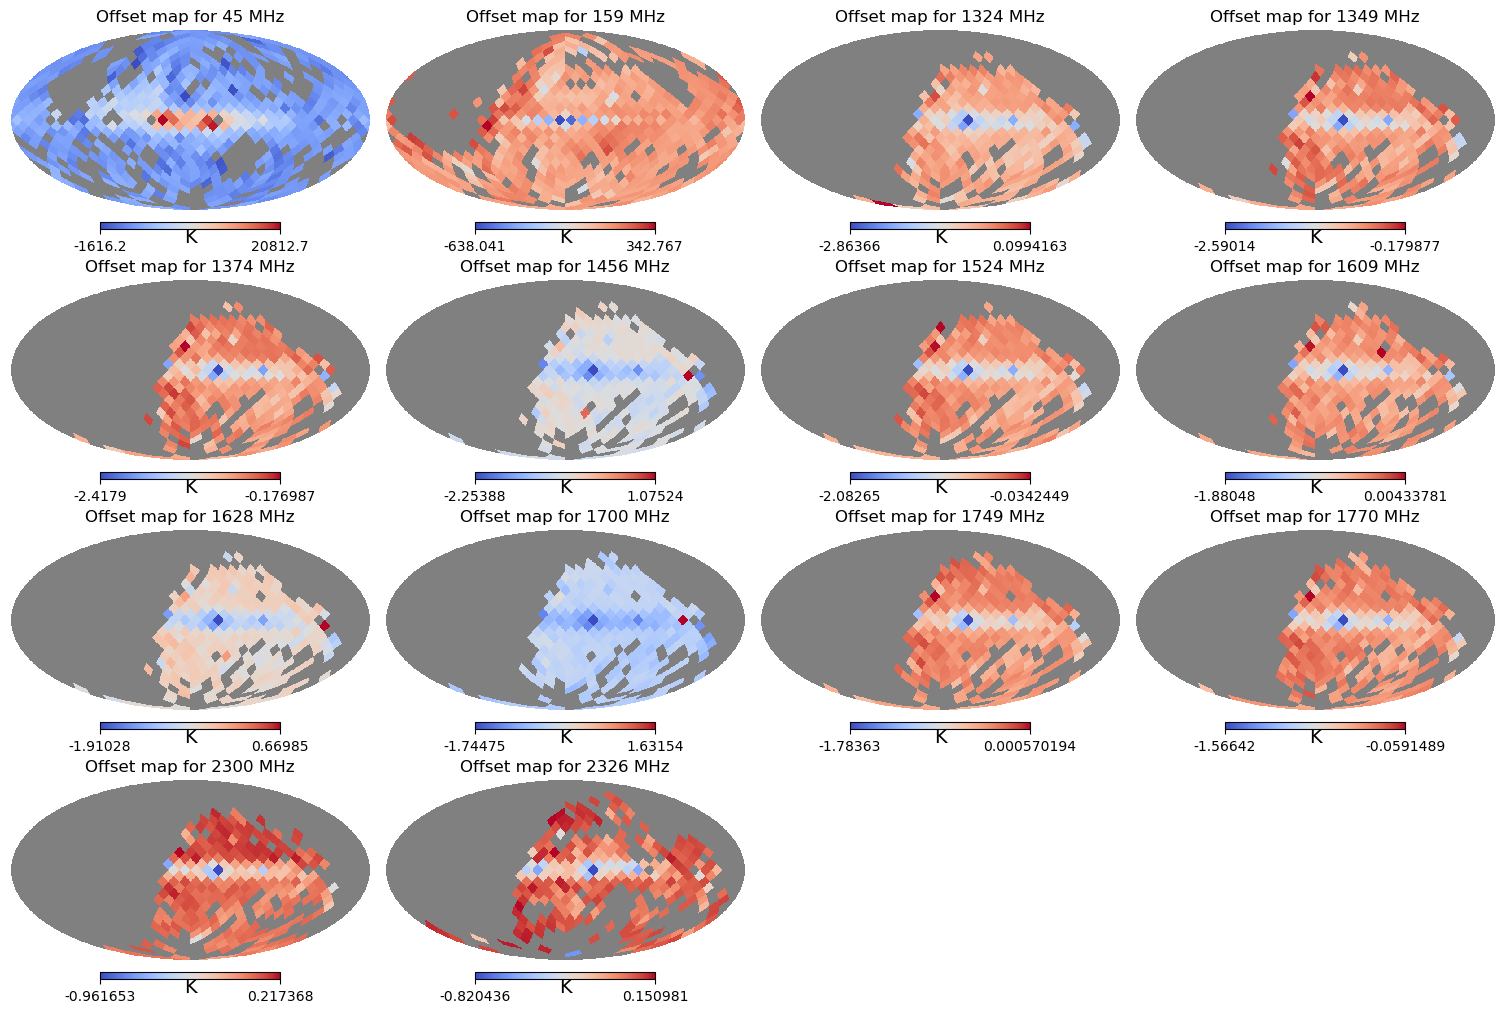

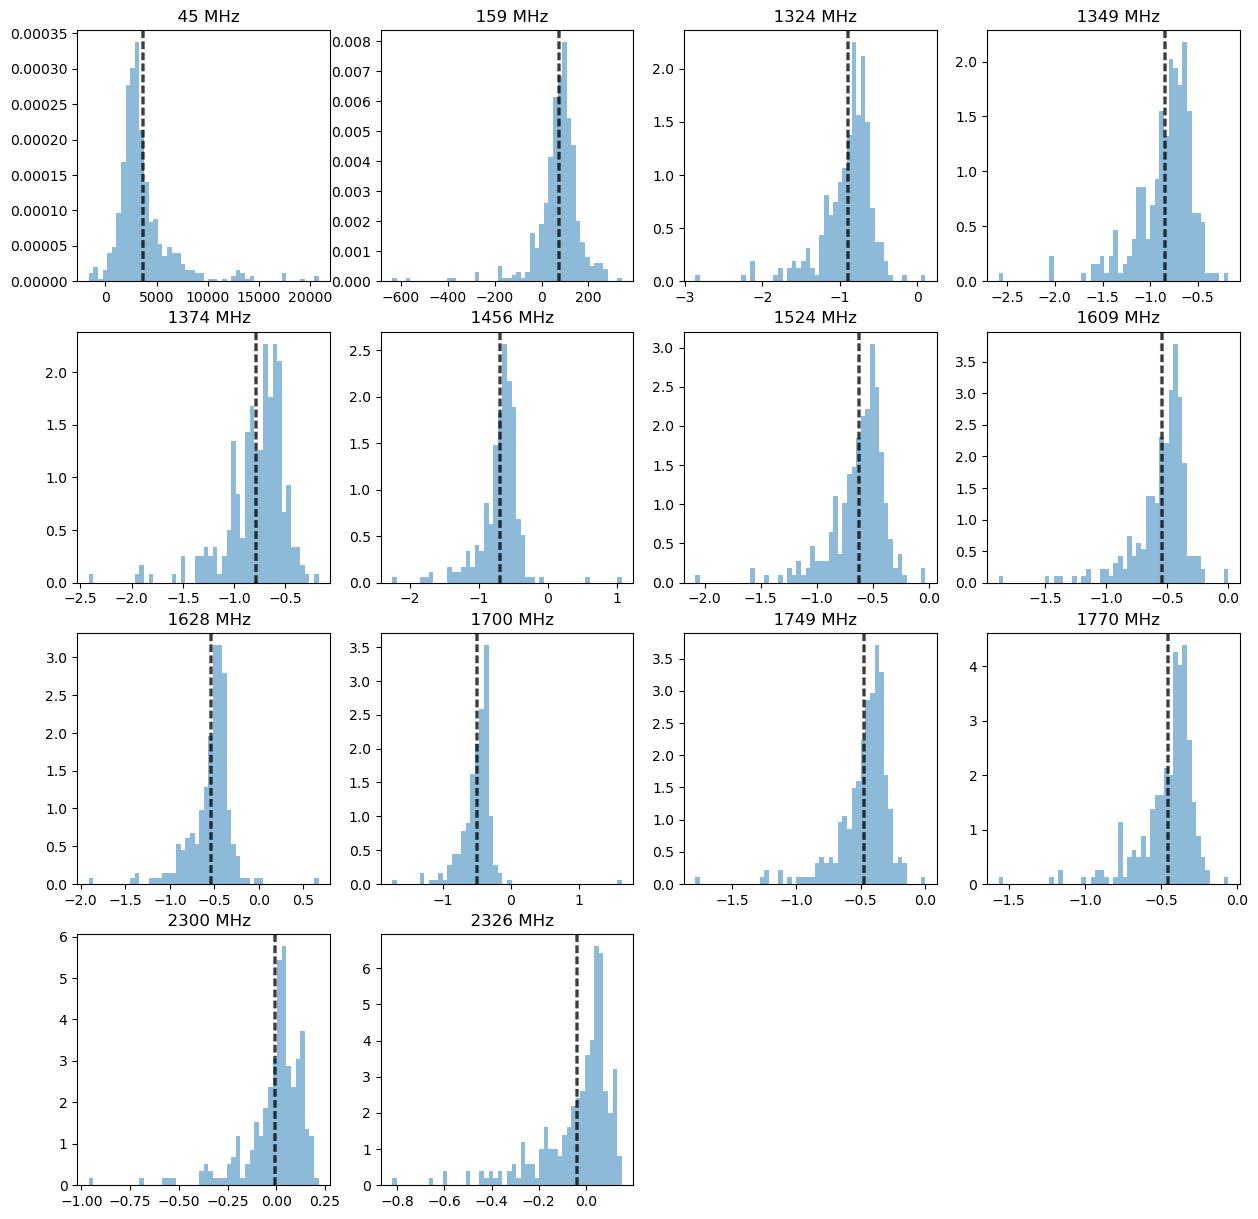

In [6]:
output_dir = "../outputs"
os.makedirs(output_dir, exist_ok=True)

j=0
pl.figure(figsize=(15, 10))

for k, offset, error_offset  , offset_map  in results:
    hp.mollview(offset_map, title=f"Offset map for {k} MHz", unit=f"{maps[k].unit}" , cmap='coolwarm',
                sub=(4,4,j+1))
    j+=1
    
offset_file = open(output_dir+'/offset_coarse_south.txt', 'w')

pl.figure(figsize=(15, 15))
j=0
for k, offset, error_offset  , offset_map  in results:
    offset_file.write("%f %f % f\n" %(k, offset.value, error_offset))
    pl.subplot(4, 4, j+1)
    pl.title(f"  {k} MHz") 
    pl.hist(np.ma.masked_invalid(offset_map ).data.flatten(), bins=50, label=f"{k} MHz", alpha=0.5, density=True)
    pl.axvline ( offset.value,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    pl.axvline ( offset.value -error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    pl.axvline ( offset.value +error_offset ,ymax=1,linestyle=   '--', color='k', alpha=0.5)
    j+=1

offset_file.close()

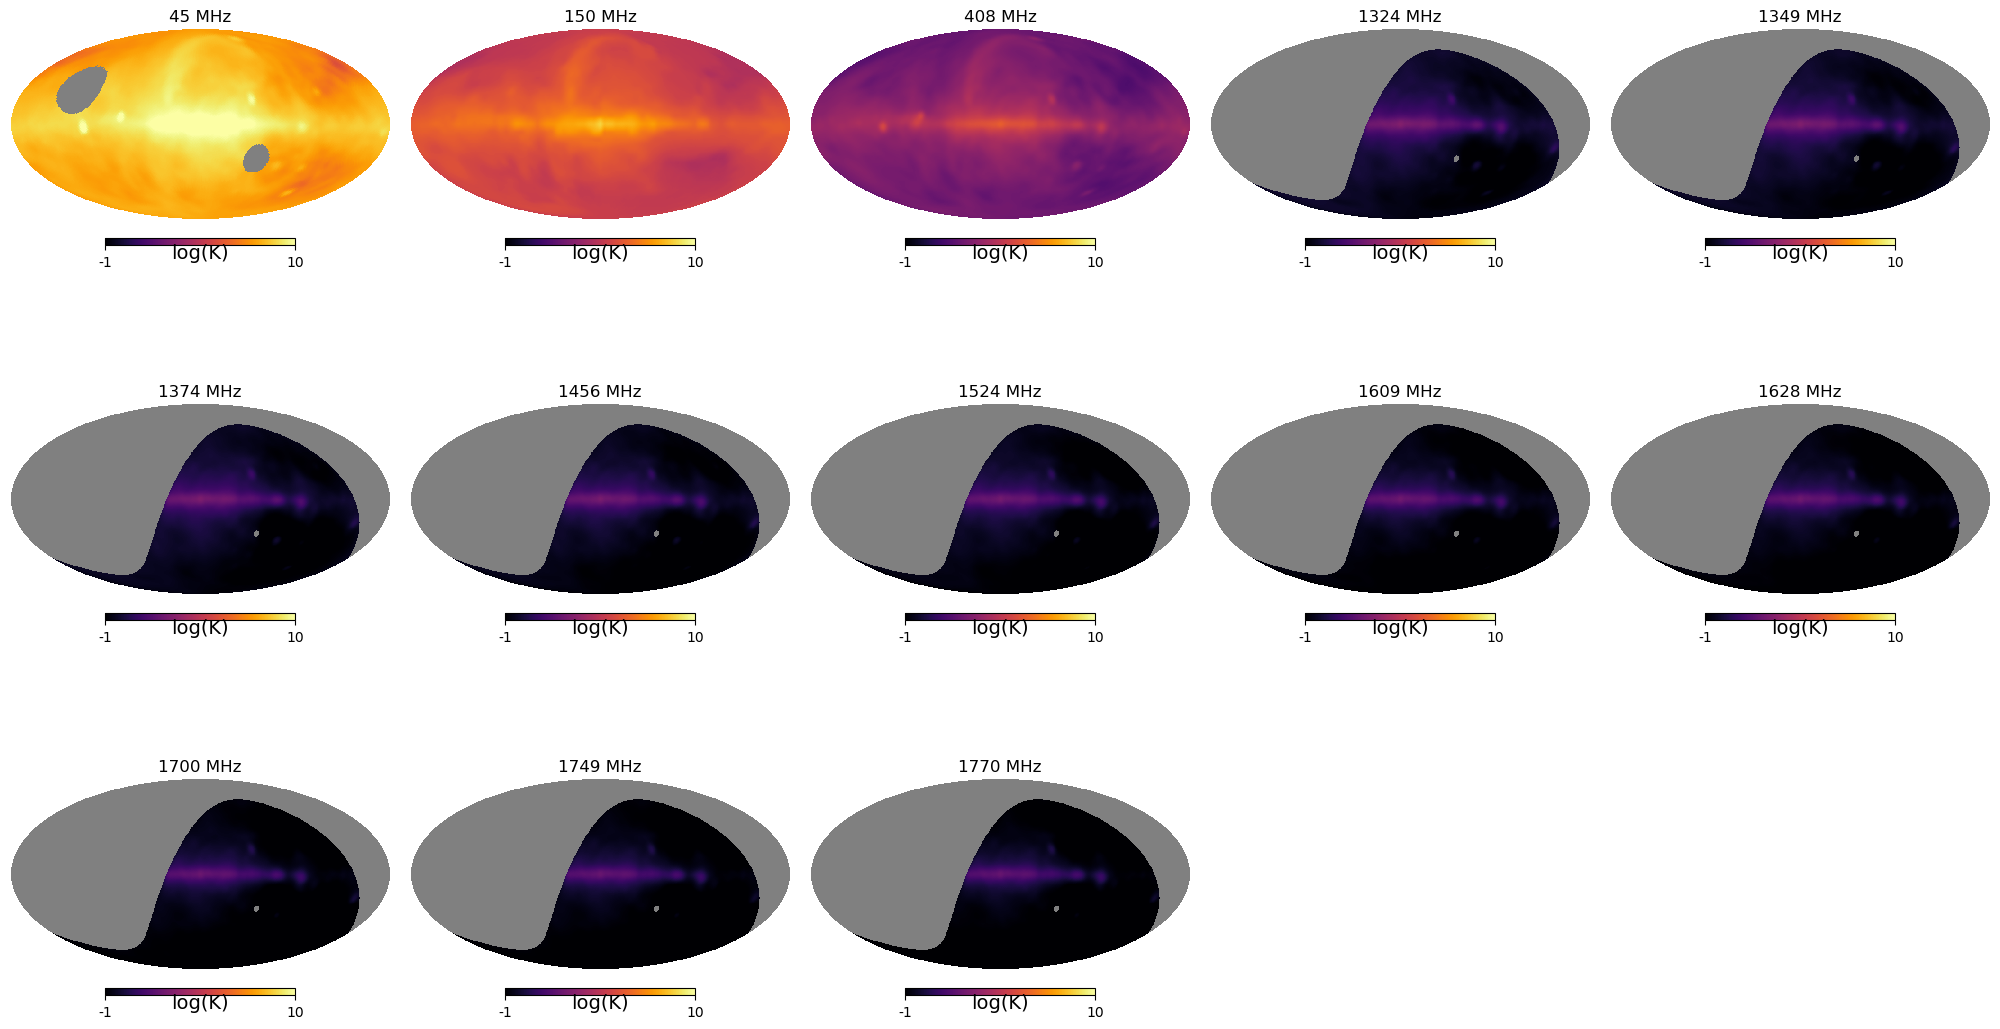

In [26]:
pl.figure(figsize=(20,15)) 

j=0
for fr,m in maps.items():
     
    hp.mollview(np.log (m.value),  title=f'{fr} MHz'  , sub=(4,5,1+j) , notext=True ,  min=-1,  max=10 , unit = f'log({m.unit})'   , cmap='inferno')
    
    j+=1



## Save maps

In [ ]:

from astropy.table import Table
t = Table([m for m in maps.values() ] , names=(m for m in maps.keys()))

t.write(f'../inputmaps/coarse_south_maps_nside{nside}.fits', format='fits', overwrite=True )

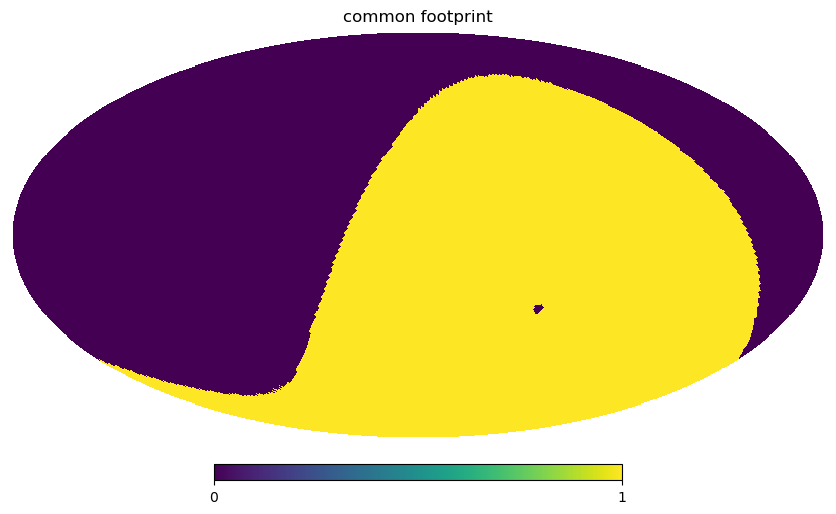

In [8]:
#chipass_nans = np.ma.masked_invalid(maps[1400] ).mask   
#jonas_nans = np.ma.masked_invalid(maps[2326]).mask
jonas_nans = np.ma.masked_invalid(maps[1770]).mask
mu_mask=  np.ma.masked_invalid(maps[45]).mask
common_footprint =  np.logical_and(~jonas_nans , ~mu_mask)  
hp.mollview(common_footprint, title='common footprint' ) 


In [9]:
hp.write_map(
    f"{output_dir}/common_footprint_southern.fits",
    common_footprint.astype(np.float32),
    overwrite=True
)

setting the output map dtype to [dtype('float32')]


In [17]:
# Save all maps into a single HEALPix FITS file
hp.write_map(
    f"{output_dir}/bfit_maps_south_11.fits",
    [betamap, csmap, fmap, error_betamap , error_csmap, error_fmap , chisquare_map ],
    column_names=["BETAMAP", "CSMAP", "FMAP","BETAMAP_ERR", "CSMAP_ERR", "FMAP_ERR" ,"CHISQUARE"  ],
    overwrite=True,
    dtype=np.float32
)
